HW 2

Этот набор данных содержит информацию о подержанных автомобилях.

- Car_Name - Название автомобиля
- Year - год в котором купил машину предыдущий владелец
- Selling_Price - цена продажи машины сейчас
- Present_Price - предыдущая цена покупки
- Kms_Driven - сколько километров проехала машина
- Fuel_Type - тип используемого топлива
- Seller_Type - тип продавца
- Transmission - тип коробки передач
- Owner - количество владельцев автомобиля до текущего хозяина

Целевой переменной считать - Selling_Price.

1. После загрузки необходимо проанализировать существующие признаки.
2. Определите какие признаки являются числовыми, а какие категориальными (кодом!) Выведите список одних и других.
3. Используйте стратегию валидации Holdout. Постройте линейную регрессию на числовых признаках. Оцените качество работы с помощью метрик MSE и MAE.
4. Проанализируйте важность признаков без библиотеки yellowbrick.
5. Сравните результат вашего анализа с результатов yellowbrick.
6. Добавьте категориальные признаки при помощи метода sklearn.preprocessing.OneHotEncoder. [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) + [Пример использования](https://www.dmitrymakarov.ru/data-analysis/encoding-10/#10-klass-onehotencoder)
7. Переобучите модель. Также проанализируйте важность признаков, что изменилось? А как изменились метрики?
8. Добавьте регуляризацию (3 типа). Как меняется важность признаков? Как изменяются метрики?
9. Добавьте [Learning Curve](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html) для одной из моделей. [Визуализируйте результат!](https://scikit-learn.org/stable/auto_examples/model_selection/plot_learning_curve.html#sphx-glr-auto-examples-model-selection-plot-learning-curve-py)

In [76]:
# Импорты

import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from yellowbrick.model_selection import FeatureImportances
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [57]:
# Загрузка данных
sharing_url = "https://drive.google.com/file/d/1qeae-8oAfQnULTs838ROpupXLvMNwtiO/view?usp=sharing"
download_url = "https://drive.google.com/uc?id=" + sharing_url.split("/")[-2]

df = pd.read_csv(download_url)

In [58]:
df.head(2)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [60]:
print(df.describe())

              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [61]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [62]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("\nЧисловые признаки", numerical_features)
print("Категориальные признаки", categorical_features)


Числовые признаки ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']
Категориальные признаки ['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission']


In [63]:
target = "Selling_Price"
X = df[numerical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

mse = mean_squared_error(y_test, pred)
mae = mean_absolute_error(y_test, pred)

print("MSE:", mse)
print("MAE:", mae)

MSE: 2.5638822261398733e-23
MAE: 3.8502220537489365e-12


Selling_Price    1.000000e+00
Year             2.318784e-12
Present_Price    2.392222e-14
Kms_Driven       1.110223e-16
Owner            6.974342e-17
dtype: float64


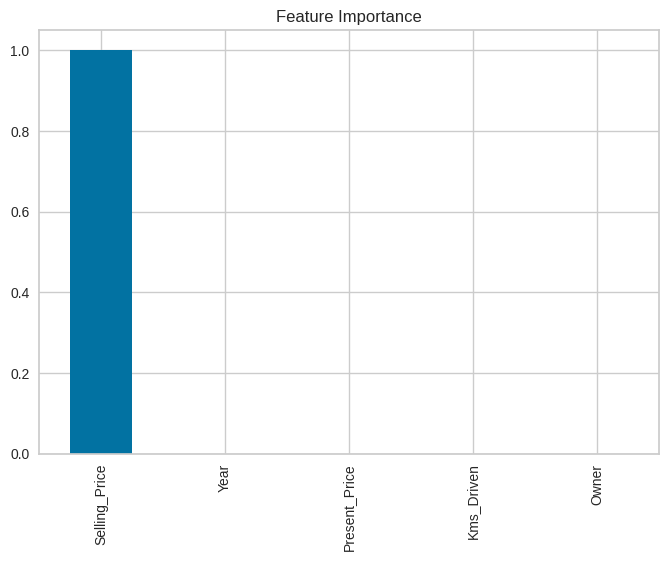

In [64]:
importance = pd.Series(
    abs(model.coef_),
    index=numerical_features
).sort_values(ascending=False)

print(importance)

importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


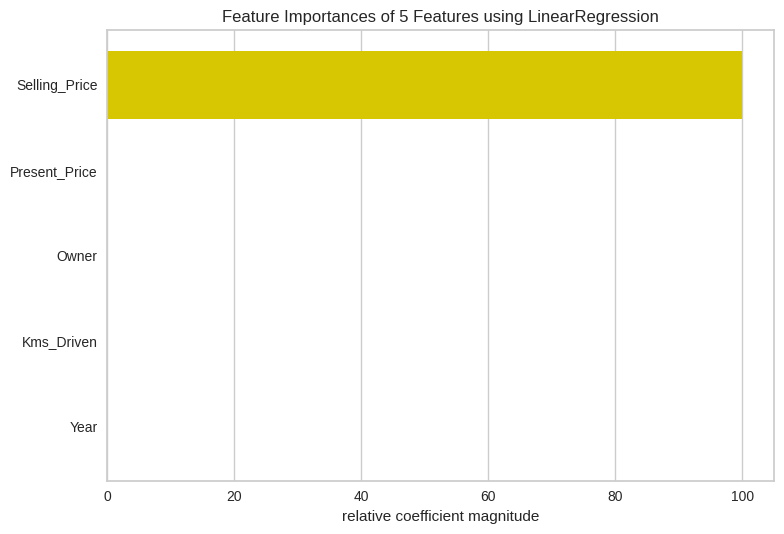

<Axes: title={'center': 'Feature Importances of 5 Features using LinearRegression'}, xlabel='relative coefficient magnitude'>

In [65]:
viz = FeatureImportances(model)
viz.fit(X_train, y_train)
viz.show()

In [66]:
X = df.drop(columns=[target])
y = df[target]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [67]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)

MSE: 2.6677460908209834
MAE: 1.059054419296891


После добавления категориальных признаков с использованием OneHotEncoder и повторного обучения модели значения метрик стали более реалистичными

In [69]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train[numeric_features], y_train)

pred = ridge.predict(X_test[numeric_features])

print("Ridge MSE:", mean_squared_error(y_test, pred))
print("Ridge MAE:", mean_absolute_error(y_test, pred))

Ridge MSE: 4.115870897166295
Ridge MAE: 1.3923664010809458


In [72]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train[numeric_features], y_train)

pred = lasso.predict(X_test[numeric_features])

print("Lasso MSE:", mean_squared_error(y_test, pred))
print("Lasso MAE:", mean_absolute_error(y_test, pred))

Lasso MSE: 4.0592555016692575
Lasso MAE: 1.3703320249794808


In [73]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.1)
elastic.fit(X_train[numeric_features], y_train)

pred = elastic.predict(X_test[numeric_features])

print("ElasticNet MSE:", mean_squared_error(y_test, pred))
print("ElasticNet MAE:", mean_absolute_error(y_test, pred))

ElasticNet MSE: 4.066749630163415
ElasticNet MAE: 1.3753076227307195


Добавление регуляризации увеличило значения метрик MSE и MAE по сравнению с обычной линейной регрессией. Это связано с тем, что регуляризация ограничивает значения коэффициентов модели и снижает вероятность переобучения.

Модель Ridge уменьшает значения коэффициентов, но не зануляет их. Lasso может полностью исключать некоторые признаки из модели, что помогает упростить модель. ElasticNet сочетает оба подхода.

В проведённом эксперименте наилучшие значения метрик показала модель Lasso, однако различия между моделями регуляризации оказались незначительными.

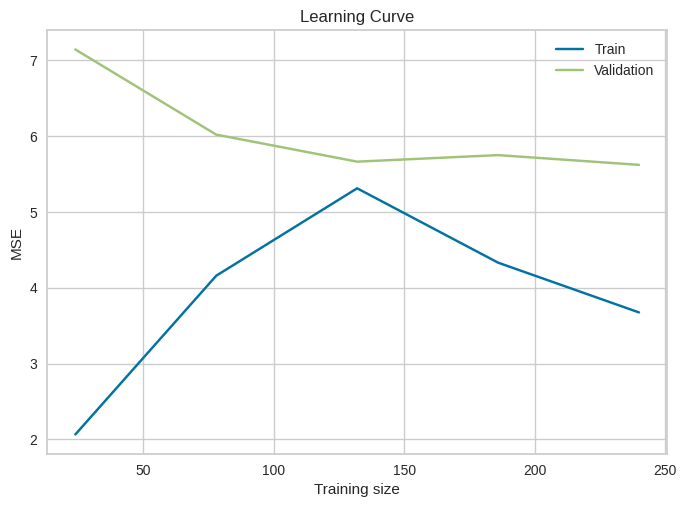

In [75]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(),
    X[numeric_features],
    y,
    cv=5,
    scoring='neg_mean_squared_error'
)

train_scores_mean = -train_scores.mean(axis=1)
test_scores_mean = -test_scores.mean(axis=1)

plt.plot(train_sizes, train_scores_mean, label="Train")
plt.plot(train_sizes, test_scores_mean, label="Validation")

plt.xlabel("Training size")
plt.ylabel("MSE")
plt.title("Learning Curve")
plt.legend()
plt.show()